In [2]:
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
%matplotlib inline


In [3]:
import cv2 as cv

def load_image(filename='./Trump.jpg'):
    # Load the new image with a clearly visible face
    img = cv.imread(filename)

    top = 10 
    w_center = int(img.shape[1] / 2)
    img = img[top:top+500, w_center-250:w_center+250]
    return img

img = load_image()


In [5]:
def filter(image, kernel):
    image = image.astype(float)
    kernel = kernel.astype(float)
    
    filtered = np.zeros_like(image)
    width = int((kernel.shape[1]-1)/2)
    height = int((kernel.shape[0]-1)/2)

    for i in range(height, image.shape[1]-height):
        for j in range(width, image.shape[0]-width):
            filtered[j,i]=np.sum(kernel*image[j-width:j+width+1,i-height:i+height+1])

    return filtered

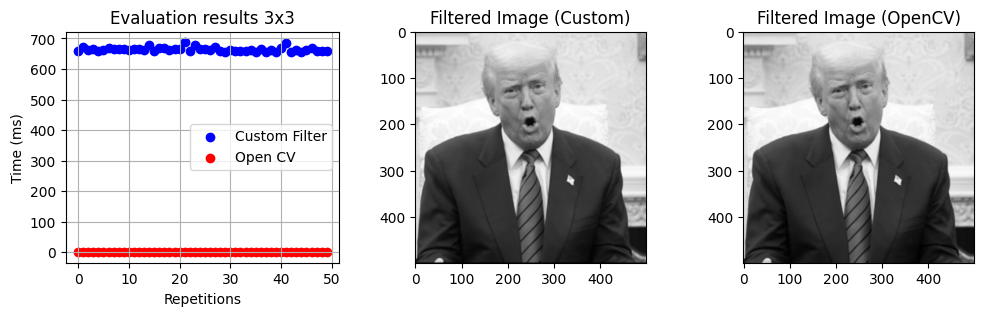

Evaluation Results for Size 3x3:
Custom Filter: Mean = 664.2310, Std = 7.1025
OpenCV Filter: Mean = 0.1860, Std = 0.0981


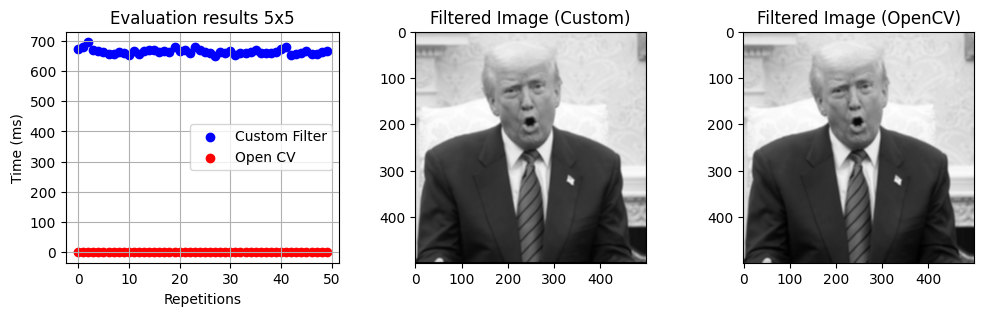

Evaluation Results for Size 5x5:
Custom Filter: Mean = 664.2237, Std = 8.3061
OpenCV Filter: Mean = 0.4196, Std = 0.0510


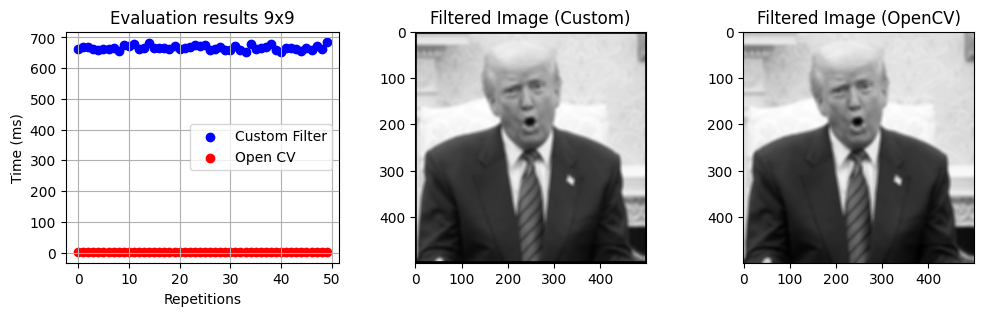

Evaluation Results for Size 9x9:
Custom Filter: Mean = 665.9286, Std = 7.3282
OpenCV Filter: Mean = 1.3184, Std = 0.1457


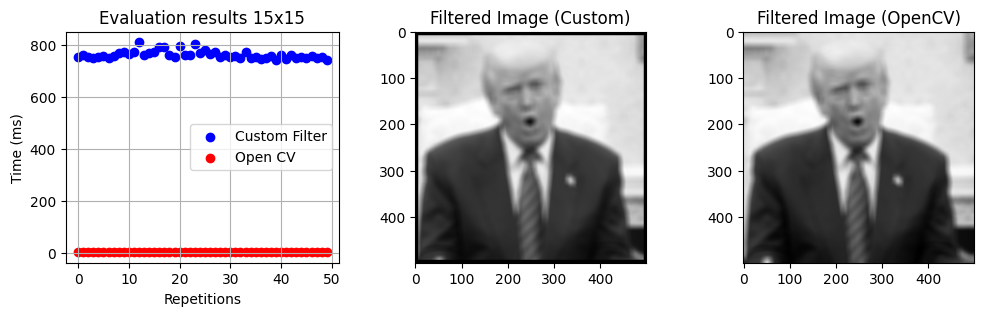

Evaluation Results for Size 15x15:
Custom Filter: Mean = 761.3190, Std = 14.8724
OpenCV Filter: Mean = 2.2062, Std = 0.3474


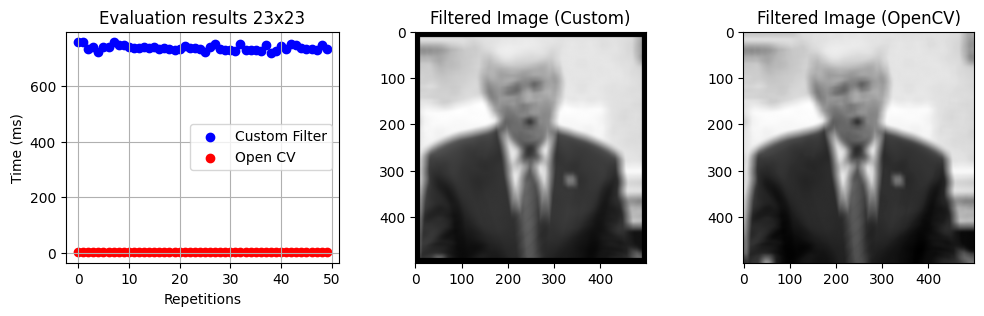

Evaluation Results for Size 23x23:
Custom Filter: Mean = 737.1140, Std = 9.0286
OpenCV Filter: Mean = 2.1915, Std = 0.2946


In [6]:
import time
import numpy as np

def record(filter_func, reps=50):
    results = []
    for _ in range(reps):
        start = time.time()
        img = filter_func()
        end = time.time()
        elapsed = (end - start) * 1000
        results.append(elapsed)

    return (results, img)


def plot_results(title, custom, cv):
    custom_result, custom_img = custom
    cv_result, cv_img = cv

    figure = plt.figure(figsize=(12, 3))

    ax = figure.add_subplot(131)
    ax.scatter(range(len(custom_result)), custom_result, label='Custom Filter', color='blue')
    ax.scatter(range(len(cv_result)), cv_result, label='Open CV', color='red')
    ax.set_xlabel('Repetitions')
    ax.set_ylabel('Time (ms)')
    #ax.set_yscale('symlog')
    ax.legend()
    ax.grid(True)
    ax.set_title(title)

    ax = figure.add_subplot(132)
    ax.imshow(custom_img, cmap='gray')
    ax.set_title('Filtered Image (Custom)')

    ax = figure.add_subplot(133)
    ax.imshow(cv_img, cmap='gray')
    ax.set_title('Filtered Image (OpenCV)')
    plt.show()


def summary_results(index, custom, cv):
    custom_result, _ = custom
    cv_result, _ = cv
    
    custom_mean = np.mean(custom_result)
    cv_mean = np.mean(cv_result)

    custom_std = np.std(custom_result)
    cv_std = np.std(cv_result)

    print(f"Evaluation Results for Size {index}x{index}:")
    print(f"Custom Filter: Mean = {custom_mean:.4f}, Std = {custom_std:.4f}")
    print(f"OpenCV Filter: Mean = {cv_mean:.4f}, Std = {cv_std:.4f}")


def evaluate():
    '''
    Next, evaluate the timing of your filter function for a 500x500 pixel grey-scale 
    image of your choice against the OpenCV function cv2.filter2D for simple,
    normalized box-filters of size 3x3, 5x5, 9x9, 15x15, 23x23. A box-filter consists of only
    “1”s in all elements of the filter and is an averaging filter.
    '''
    img = load_image()
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    filter_sizes = [3, 5, 9, 15, 23]
    reps = 50

    for size in filter_sizes:
        box_filter = np.ones((size, size)) / (size * size)

        func = lambda: filter(img, box_filter)
        custom_result = record(func, reps=reps)

        func = lambda: cv.filter2D(img, -1, box_filter)
        cv_result = record(func, reps=reps)

        plot_results(f'Evaluation results {size}x{size}', custom_result, cv_result)
        summary_results(size, custom_result, cv_result)

evaluate()
